# Visibility Functions: Literature vs PDE-Fitted Parameters

Generates `pde_visibility_fit.pdf` (Figure 1 in paper).

Compares Chluba (2013) parameterizations of J_bb*, J_mu, J_y with our PDE-derived fits. Bottom panel shows fractional residuals.

Saved: /home/bakerem/cosmoxide/notebooks/figures/pde_visibility_fit.pdf


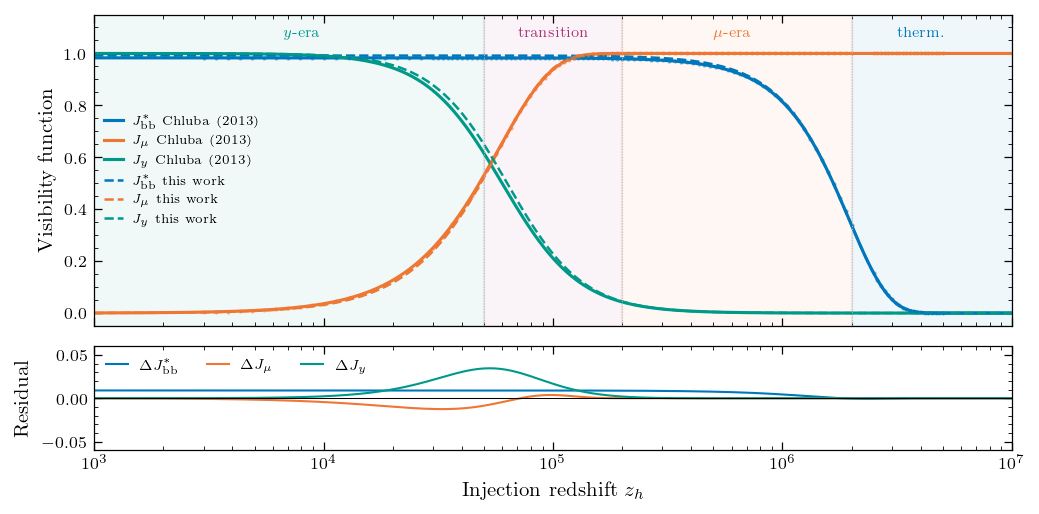

In [1]:
import os
from pathlib import Path

# Ensure cargo is on PATH
cargo_bin = Path.home() / '.cargo' / 'bin'
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(cargo_bin) + os.pathsep + os.environ.get('PATH', '')

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True)
import sys
import pathlib

import numpy as np


import matplotlib
import matplotlib.pyplot as plt
from spectroxide.style import apply_style, C, DOUBLE_COL
from spectroxide.greens import Z_MU

apply_style()

z = np.logspace(3, 7, 500)

# --- Literature (Chluba 2013) parameters ---
def j_bb_lit(z):
    return np.exp(-((z / 1.98e6) ** 2.5))

def j_bb_star_lit(z):
    r = z / 1.98e6
    return np.maximum(0.983 * j_bb_lit(z) * (1.0 - 0.0381 * r**2.29), 0.0)

def j_mu_lit(z):
    return 1.0 - np.exp(-(((1.0 + z) / 5.8e4) ** 1.88))

def j_y_lit(z):
    return 1.0 / (1.0 + ((1.0 + z) / 6.0e4) ** 2.58)


# --- New fitted parameters (spectral fit, n_points=4000, 118 z_h, x∈[0.5,20]) ---
# α_th = 5/2 and z_th = 1.98e6 fixed (analytic)
def j_bb_new(z):
    return np.exp(-((z / 1.98e6) ** 2.5))

def j_bb_star_new(z):
    r = z / 1.98e6
    return np.maximum(0.992 * j_bb_new(z) * (1.0 - 0.048 * r**2.07), 0.0)

def j_mu_new(z):
    return 1.0 - np.exp(-(((1.0 + z) / 5.843e4) ** 1.947))

def j_y_new(z):
    return 1.0 / (1.0 + ((1.0 + z) / 6.313e4) ** 2.653)


# --- Load per-spectrum PDE fits if available ---
datadir = PROJECT_ROOT / 'dev' / 'data'
tablepath = datadir / "visibility_table.npz"
has_pde = tablepath.exists()
if has_pde:
    data = np.load(tablepath)
    z_pde = data["z_h"]
    j_mu_pde = data["j_mu_fit"]
    j_bb_pde = data["j_bb_fit"]
    j_y_pde = data["j_y_fixed"]  # J_y is fixed from formula, not fitted per-spectrum


# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(DOUBLE_COL, 3.5),
                         gridspec_kw={"height_ratios": [3, 1]},
                         sharex=True)

# --- Top panel: visibility functions ---
ax = axes[0]

# Era shading
ax.axvspan(1e3, 5e4, alpha=0.06, color=C["teal"])
ax.axvspan(5e4, 2e5, alpha=0.06, color=C["purple"])
ax.axvspan(2e5, 2e6, alpha=0.06, color=C["orange"])
ax.axvspan(2e6, 1e7, alpha=0.06, color=C["blue"])
era_label_y = 1.08
ax.text(8e3, era_label_y, r"$y$-era", fontsize=7, color=C["teal"], ha="center", va="center")
ax.text(1e5, era_label_y, "transition", fontsize=7, color=C["purple"], ha="center", va="center")
ax.text(6e5, era_label_y, r"$\mu$-era", fontsize=7, color=C["orange"], ha="center", va="center")
ax.text(4e6, era_label_y, "therm.", fontsize=7, color=C["blue"], ha="center", va="center")

# Literature curves (solid)
ax.semilogx(z, j_bb_star_lit(z), color=C["blue"], lw=1.5,
            label=r"$J_{\mathrm{bb}}^*$ Chluba (2013)")
ax.semilogx(z, j_mu_lit(z), color=C["orange"], lw=1.5,
            label=r"$J_\mu$ Chluba (2013)")
ax.semilogx(z, j_y_lit(z), color=C["teal"], lw=1.5,
            label=r"$J_y$ Chluba (2013)")

# New fitted curves (dashed)
ax.semilogx(z, j_bb_star_new(z), color=C["blue"], lw=1.2, ls="--",
            label=r"$J_{\mathrm{bb}}^*$ this work")
ax.semilogx(z, j_mu_new(z), color=C["orange"], lw=1.2, ls="--",
            label=r"$J_\mu$ this work")
ax.semilogx(z, j_y_new(z), color=C["teal"], lw=1.2, ls="--",
            label=r"$J_y$ this work")

# PDE per-spectrum fits (scatter)
if has_pde:
    ax.semilogx(z_pde, j_bb_pde, ".", color=C["blue"], ms=2, alpha=0.5)
    ax.semilogx(z_pde, j_mu_pde, ".", color=C["orange"], ms=2, alpha=0.5)

ax.axvline(5e4, color=C["gray"], ls=":", lw=0.5)
ax.axvline(2e5, color=C["gray"], ls=":", lw=0.5)
ax.axvline(2e6, color=C["gray"], ls=":", lw=0.5)

ax.set_ylabel("Visibility function")
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=6, loc="center left", ncol=1)

# --- Bottom panel: absolute difference ---
ax2 = axes[1]
ax2.semilogx(z, j_bb_star_new(z) - j_bb_star_lit(z), color=C["blue"], lw=1.0,
             label=r"$\Delta J_{\mathrm{bb}}^*$")
ax2.semilogx(z, j_mu_new(z) - j_mu_lit(z), color=C["orange"], lw=1.0,
             label=r"$\Delta J_\mu$")
ax2.semilogx(z, j_y_new(z) - j_y_lit(z), color=C["teal"], lw=1.0,
             label=r"$\Delta J_y$")

ax2.axhline(0, color="k", lw=0.5)
ax2.set_xlabel(r"Injection redshift $z_h$")
ax2.set_ylabel("Residual")
ax2.set_xlim(1e3, 1e7)
ax2.set_ylim(-0.06, 0.06)
ax2.legend(fontsize=7, loc="upper left", ncol=3)

fig.tight_layout()
outpath = FIG_DIR / 'pde_visibility_fit.pdf'
fig.savefig(outpath)
print(f"Saved: {outpath}")